# Telemetry Under Concurrency: Isolation vs Concurrent Execution
## TPC-H SF20 on Firebolt

**Research question:** How does concurrency affect per-query telemetry?

Data is collected by `collect_concurrency.py`, which runs each of the 22
TPC-H queries at varying concurrency levels (1, 2, 4, 8) and records
per-execution telemetry from `engine_query_history`.

```bash
python collect_concurrency.py tpch20 --concurrency 1 2 4 8 --rounds 3
```

This notebook **only** loads the resulting JSON and performs analysis.

**Metrics per execution:**
- `cpu_ms` — engine-reported CPU time (milliseconds)
- `scanned_bytes` — bytes read from storage
- `duration_ms` — engine-reported wall-clock duration (milliseconds)
- `wall_ms` — client-side wall-clock (includes network + history polling)

**Core comparison:** telemetry in isolation (C=1) vs telemetry under
concurrency (C=2, 4, 8).

In [ ]:
import json
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_DIR    = Path('./metrics_witho/output')
INPUT_DIR   = Path('./metrics_witho/input')
RESULT_FILE = DATA_DIR / 'concurrency_telemetry_firebolt.json'
QUERY_FILE  = INPUT_DIR / 'TPCH-tpch20g-sql-input-standard.json'

# Import structural extraction from collision analysis module
sys.path.insert(0, str(Path('.').resolve()))
from telemetry_collision_analysis import extract_structure, classify_query_type, QueryStructure

## 1. Load experiment results

In [2]:
with open(RESULT_FILE) as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
df = df[df['ok']].copy()
df['query_label'] = df['query_idx'].apply(lambda i: f'Q{i+1:02d}')

CONCURRENCY_LEVELS = sorted(df['concurrency'].unique())

print(f'{len(df)} successful executions')
print(f'Queries:     {df["query_idx"].nunique()}')
print(f'Concurrency: {CONCURRENCY_LEVELS}')
print(f'Rounds:      {df.groupby(["query_idx","concurrency"])["round"].nunique().max()}')
df.head()

910 successful executions
Queries:     22
Concurrency: [np.int64(1), np.int64(2), np.int64(4), np.int64(8)]
Rounds:      3


,query_idx,concurrency,round,copy,cpu_ms,scanned_bytes,duration_ms,wall_ms,query_id,ok,skipped,query_label
0,0,1,0,0,21102.314,6719698048,2698.269,2701.342821,3efb7aaa-e90a-4061-9d28-c748f6cb40bb,True,NaN,Q01
1,0,1,1,0,22667.521,6719698048,2863.933,2866.567850,67b8cf89-bf66-4eef-b821-d4b6f9837c31,True,NaN,Q01
2,0,1,2,0,19807.776,6719698048,2512.265,2514.105558,296a27cd-e95d-41e8-9094-b9241632c5c7,True,NaN,Q01
3,0,2,0,0,31853.566,6719698048,4584.128,4587.554216,d37dc874-b61d-457a-800d-2d5e42612dfa,True,NaN,Q01
4,0,2,0,1,31603.303,6719698048,4584.673,4586.683273,c68d037d-94c4-4fcd-805a-c87a7262057b,True,NaN,Q01


## 1b. Extract structural features per query

Use `extract_structure()` from `telemetry_collision_analysis.py` to get
count-level features (num_tables, num_joins, num_subqueries, num_aggregations,
num_predicates) plus boolean flags for each of the 22 TPC-H queries.

In [ ]:
# Load raw SQL texts
with open(QUERY_FILE) as f:
    raw_queries = json.load(f)

struct_rows = []
for qi, entry in enumerate(raw_queries):
    sql = entry['query']
    if '@' in sql:
        sql = sql[:sql.rfind('@')]
    sql = sql.strip()

    feat = extract_structure(sql)
    feat['query_idx'] = qi
    feat['query_label'] = f'Q{qi+1:02d}'

    # Build a QueryStructure just to get classify_query_type
    qs = QueryStructure(
        query_text=sql, source=f'TPCH-Q{qi+1}',
        avg_cpu_time=0, avg_scan_bytes=0, avg_duration=0,
        has_filter=False, has_join=feat['num_joins'] > 0,
        has_agg=feat['num_aggregations'] > 0, has_sort=False,
        **{k: v for k, v in feat.items()
           if k not in ('query_idx', 'query_label')},
    )
    feat['query_type'] = classify_query_type(qs)
    struct_rows.append(feat)

struct_df = pd.DataFrame(struct_rows)

display_cols = ['query_label', 'num_tables', 'num_joins', 'num_subqueries',
                'num_aggregations', 'num_predicates', 'query_type']
display(struct_df[display_cols].set_index('query_label'))

## 2. Aggregate: per-query means at each concurrency level

For each `(query, concurrency)` pair we average across all rounds and copies.

In [3]:
agg = (
    df.groupby(['query_idx', 'query_label', 'concurrency'])
    .agg(
        cpu_ms_mean       = ('cpu_ms',        'mean'),
        cpu_ms_std        = ('cpu_ms',        'std'),
        scan_bytes_mean   = ('scanned_bytes', 'mean'),
        scan_bytes_std    = ('scanned_bytes', 'std'),
        duration_ms_mean  = ('duration_ms',   'mean'),
        duration_ms_std   = ('duration_ms',   'std'),
        wall_ms_mean      = ('wall_ms',       'mean'),
        wall_ms_std       = ('wall_ms',       'std'),
        n                 = ('ok',            'count'),
    )
    .reset_index()
)

# Coefficient of variation
for m in ['cpu_ms', 'scan_bytes', 'duration_ms', 'wall_ms']:
    agg[f'{m}_cv'] = agg[f'{m}_std'] / agg[f'{m}_mean'].replace(0, np.nan)

agg.head(10)

,query_idx,query_label,concurrency,cpu_ms_mean,cpu_ms_std,scan_bytes_mean,scan_bytes_std,duration_ms_mean,duration_ms_std,wall_ms_mean,wall_ms_std,n,cpu_ms_cv,scan_bytes_cv,duration_ms_cv,wall_ms_cv
0,0,Q01,1,21192.537000,1432.005764,6.719698e+09,0.0,2691.489000,175.932009,2694.005410,176.345669,3,0.067571,0.0,0.065366,0.065459
1,0,Q01,2,32190.119167,556.129743,6.719698e+09,0.0,4792.052000,176.085470,4794.663509,175.943851,6,0.017276,0.0,0.036745,0.036696
2,0,Q01,4,33969.321667,483.194682,6.719698e+09,0.0,9706.036750,250.897393,9709.892670,250.097160,12,0.014224,0.0,0.025850,0.025757
3,0,Q01,8,36251.138750,361.374830,6.719698e+09,0.0,20692.947792,511.903729,20700.145513,510.314359,24,0.009969,0.0,0.024738,0.024653
4,1,Q02,1,4308.909333,135.653039,7.904234e+08,0.0,659.528667,4.391081,661.769231,4.361386,3,0.031482,0.0,0.006658,0.006590
5,1,Q02,2,5857.139833,98.624302,7.904234e+08,0.0,988.283667,44.535245,991.211891,44.331715,6,0.016838,0.0,0.045063,0.044725
6,1,Q02,4,6526.934583,77.078759,7.904234e+08,0.0,2086.959250,58.443960,2091.411710,57.525217,12,0.011809,0.0,0.028004,0.027505
7,1,Q02,8,6784.459833,96.136990,7.904234e+08,0.0,3974.177042,278.193491,3981.242577,277.400122,24,0.014170,0.0,0.070000,0.069677
8,2,Q03,1,16265.294333,336.616068,3.425870e+09,0.0,2215.446667,35.671477,2217.790047,35.738536,3,0.020695,0.0,0.016101,0.016114
9,2,Q03,2,21228.974333,380.681155,3.425870e+09,0.0,3447.895000,410.009088,3450.725794,410.188999,6,0.017932,0.0,0.118916,0.118870


## 3. Build isolation baseline & compute ratios

Baseline = concurrency-1 mean for each query.  Ratio = `metric(C) / metric(C=1)`,
so 1.0 means "no change from isolation".

In [4]:
baseline = agg[agg['concurrency'] == 1].set_index('query_idx')

ratio_rows = []
for _, row in agg.iterrows():
    qi = row['query_idx']
    C  = row['concurrency']
    b  = baseline.loc[qi]
    ratio_rows.append({
        'query_idx':   qi,
        'query_label': row['query_label'],
        'concurrency': C,
        'cpu_ratio':      row['cpu_ms_mean']      / max(b['cpu_ms_mean'], 1e-9),
        'scan_ratio':     row['scan_bytes_mean']   / max(b['scan_bytes_mean'], 1),
        'duration_ratio': row['duration_ms_mean']  / max(b['duration_ms_mean'], 1e-9),
        'wall_ratio':     row['wall_ms_mean']      / max(b['wall_ms_mean'], 1e-9),
        'cpu_cv':         row['cpu_ms_cv'],
        'duration_cv':    row['duration_ms_cv'],
    })

ratios = pd.DataFrame(ratio_rows)
ratios.head(10)

,query_idx,query_label,concurrency,cpu_ratio,scan_ratio,duration_ratio,wall_ratio,cpu_cv,duration_cv
0,0,Q01,1,1.000000,1.0,1.000000,1.000000,0.067571,0.065366
1,0,Q01,2,1.518937,1.0,1.780446,1.779753,0.017276,0.036745
2,0,Q01,4,1.602891,1.0,3.606196,3.604259,0.014224,0.025850
3,0,Q01,8,1.710562,1.0,7.688290,7.683780,0.009969,0.024738
4,1,Q02,1,1.000000,1.0,1.000000,1.000000,0.031482,0.006658
5,1,Q02,2,1.359309,1.0,1.498470,1.497821,0.016838,0.045063
6,1,Q02,4,1.514753,1.0,3.164319,3.160334,0.011809,0.028004
7,1,Q02,8,1.574519,1.0,6.025784,6.016059,0.014170,0.070000
8,2,Q03,1,1.000000,1.0,1.000000,1.000000,0.020695,0.016101
9,2,Q03,2,1.305170,1.0,1.556298,1.555930,0.017932,0.118916


---
# Analysis

## RQ1: Overall telemetry distortion under concurrency

Box-plots of per-query ratios (relative to isolation) for each metric.

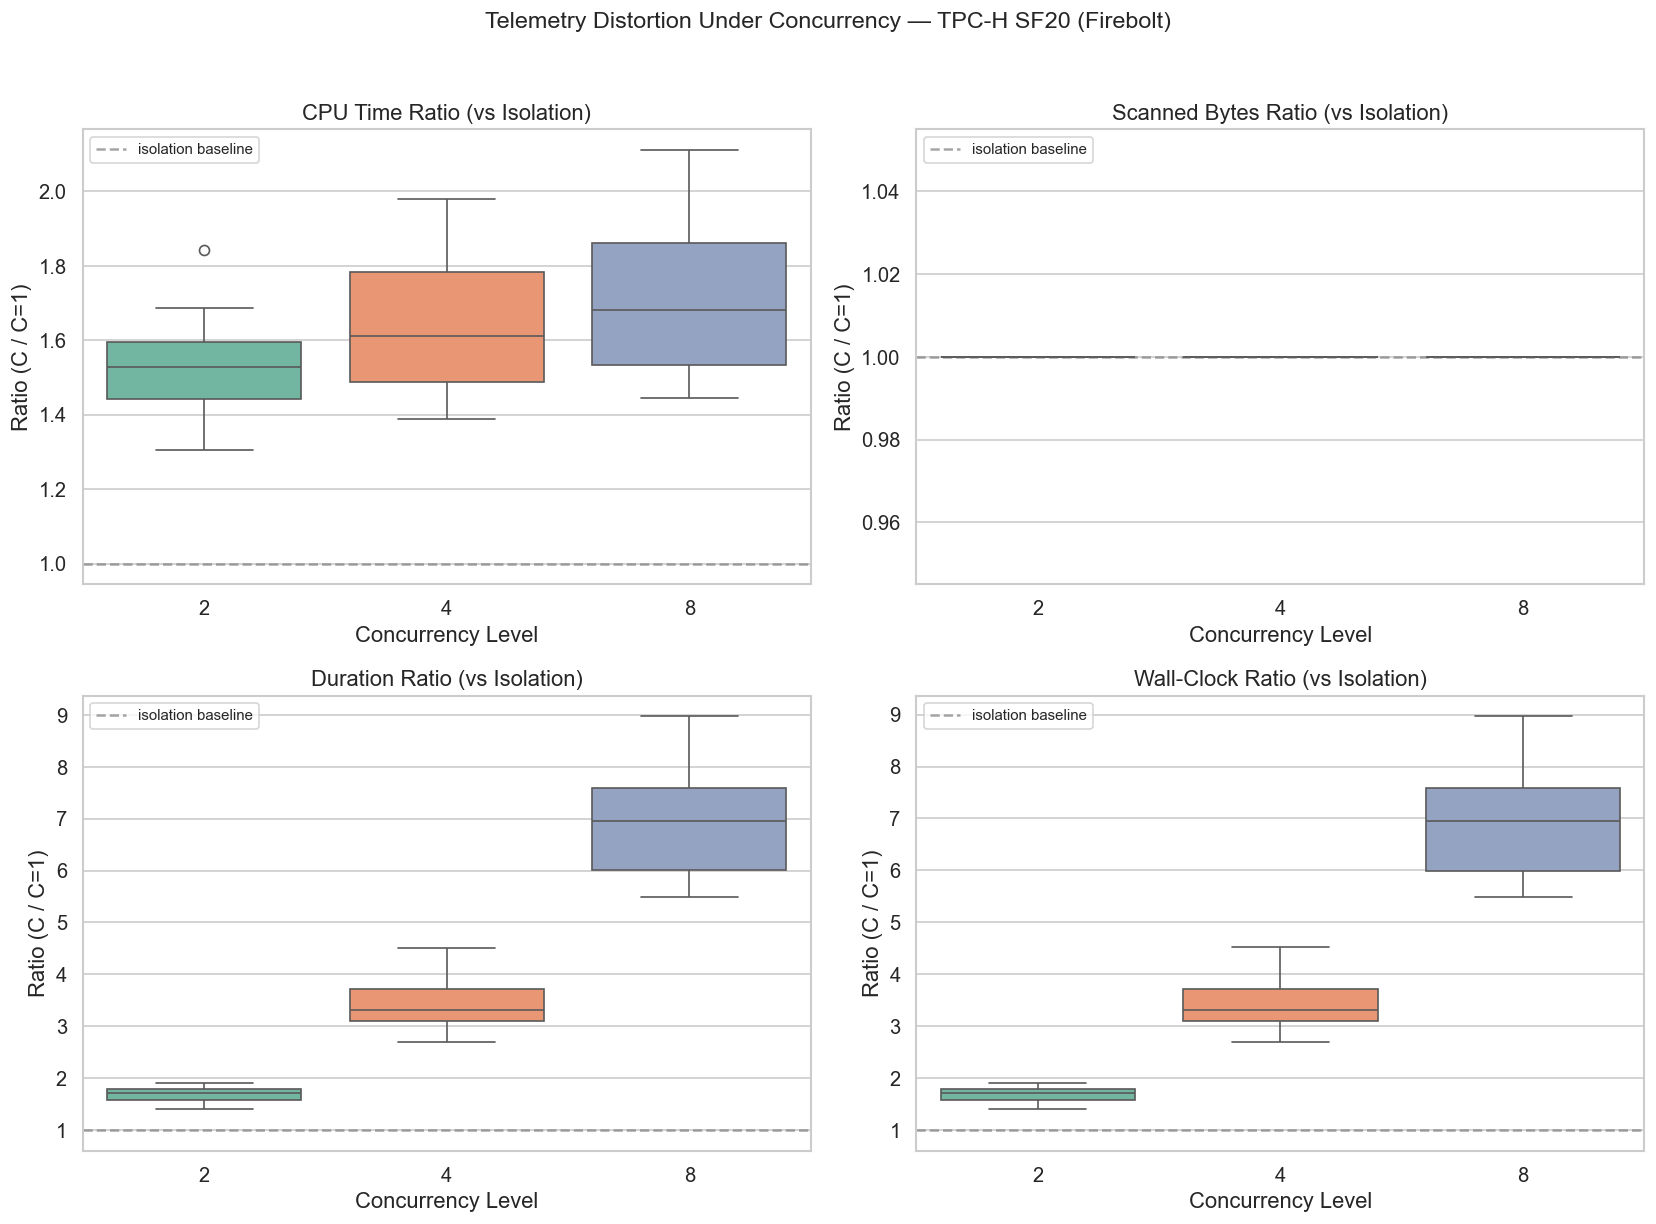

In [5]:
metrics_to_plot = [
    ('cpu_ratio',      'CPU Time Ratio (vs Isolation)'),
    ('scan_ratio',     'Scanned Bytes Ratio (vs Isolation)'),
    ('duration_ratio', 'Duration Ratio (vs Isolation)'),
    ('wall_ratio',     'Wall-Clock Ratio (vs Isolation)'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col, title) in zip(axes.flat, metrics_to_plot):
    data = ratios[ratios['concurrency'] > 1]
    sns.boxplot(data=data, x='concurrency', y=col, ax=ax, palette='Set2')
    ax.axhline(1.0, ls='--', color='grey', alpha=0.7, label='isolation baseline')
    ax.set_title(title)
    ax.set_xlabel('Concurrency Level')
    ax.set_ylabel('Ratio (C / C=1)')
    ax.legend(loc='upper left', fontsize=9)

fig.suptitle('Telemetry Distortion Under Concurrency — TPC-H SF20 (Firebolt)',
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## RQ2: Per-query telemetry shift

Heatmap of per-query ratios at each concurrency level.

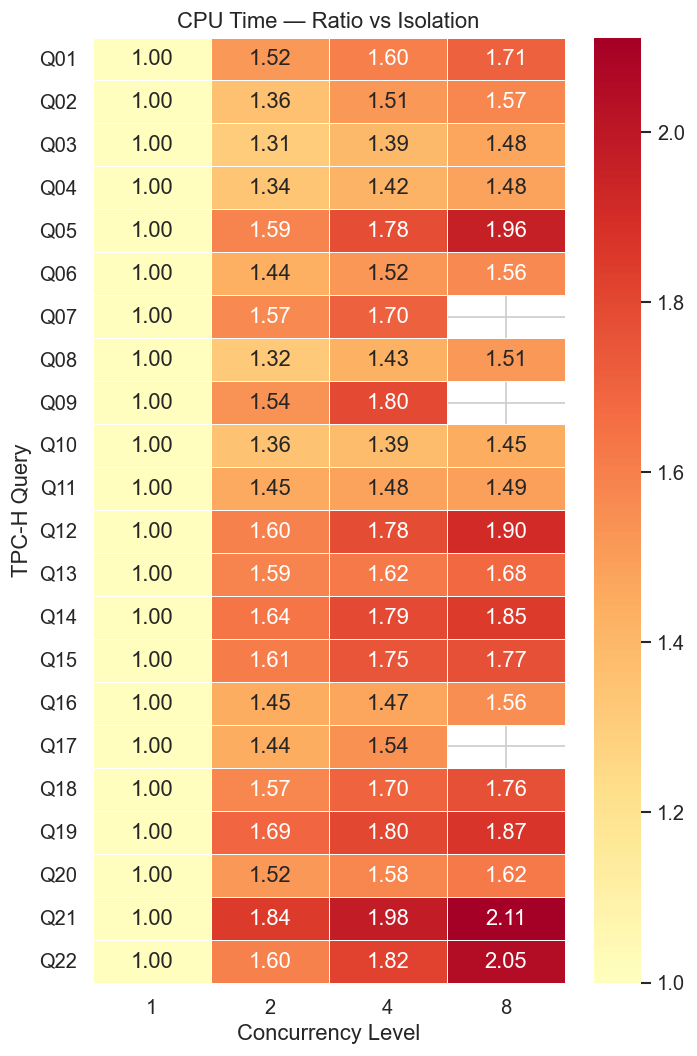

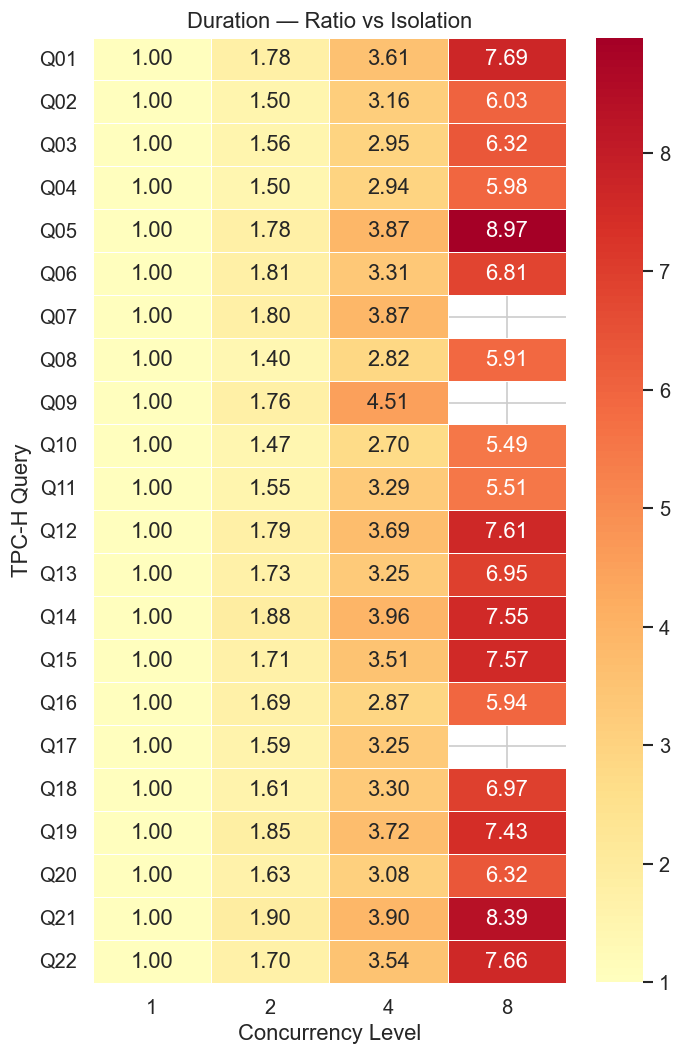

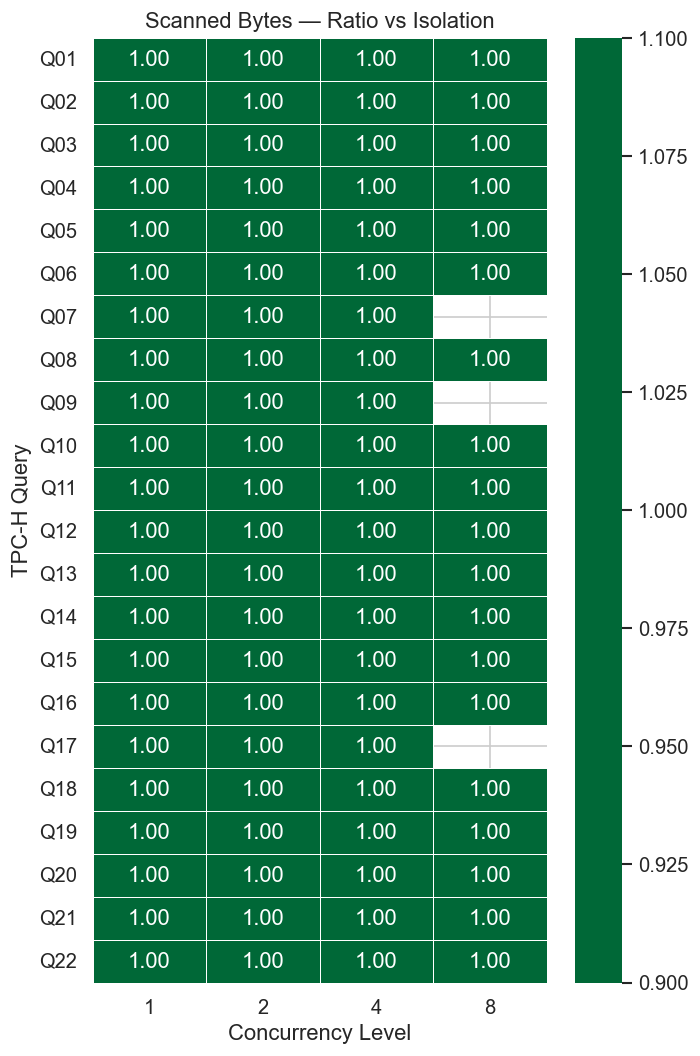

In [6]:
for col, title in [('cpu_ratio', 'CPU Time'), ('duration_ratio', 'Duration'),
                    ('scan_ratio', 'Scanned Bytes')]:
    pivot = ratios.pivot(index='query_label', columns='concurrency', values=col)
    pivot = pivot.sort_index()

    fig, ax = plt.subplots(figsize=(6, 9))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r', center=1.0,
                linewidths=0.5, ax=ax)
    ax.set_title(f'{title} — Ratio vs Isolation')
    ax.set_ylabel('TPC-H Query')
    ax.set_xlabel('Concurrency Level')
    fig.tight_layout()
    plt.show()

## RQ3: Rank stability under concurrency

Spearman and Kendall rank correlation between the isolation ranking and
the ranking at each concurrency level.

In [7]:
rank_metrics = ['cpu_ms_mean', 'scan_bytes_mean', 'duration_ms_mean']
nice_names   = ['CPU Time', 'Scanned Bytes', 'Duration']

baseline = agg[agg['concurrency'] == 1].set_index('query_idx')

rank_corr_rows = []
for C in CONCURRENCY_LEVELS:
    sub = agg[agg['concurrency'] == C].set_index('query_idx')
    common = baseline.index.intersection(sub.index)
    for m, nice in zip(rank_metrics, nice_names):
        b_rank = baseline.loc[common, m].rank()
        r_c    = sub.loc[common, m].rank()
        rho, pval = stats.spearmanr(b_rank, r_c)
        tau, tp   = stats.kendalltau(b_rank, r_c)
        rank_corr_rows.append({
            'concurrency': C,
            'metric': nice,
            'spearman_rho': rho,
            'spearman_p':   pval,
            'kendall_tau':  tau,
            'kendall_p':    tp,
            'n_queries':    len(common),
        })

rank_df = pd.DataFrame(rank_corr_rows)
display(rank_df.style.format({
    'spearman_rho': '{:.4f}', 'spearman_p': '{:.4f}',
    'kendall_tau':  '{:.4f}', 'kendall_p':  '{:.4f}',
}).background_gradient(subset=['spearman_rho'], cmap='RdYlGn', vmin=0, vmax=1))

,concurrency,metric,spearman_rho,spearman_p,kendall_tau,kendall_p,n_queries
0,1,CPU Time,1.0000,0.0000,1.0000,0.0000,22
1,1,Scanned Bytes,1.0000,0.0000,1.0000,0.0000,22
2,1,Duration,1.0000,0.0000,1.0000,0.0000,22
3,2,CPU Time,0.9932,0.0000,0.9654,0.0000,22
4,2,Scanned Bytes,1.0000,0.0000,1.0000,0.0000,22
5,2,Duration,0.9966,0.0000,0.9740,0.0000,22
6,4,CPU Time,0.9921,0.0000,0.9567,0.0000,22
7,4,Scanned Bytes,1.0000,0.0000,1.0000,0.0000,22
8,4,Duration,0.9910,0.0000,0.9481,0.0000,22
9,8,CPU Time,0.9877,0.0000,0.9415,0.0000,19


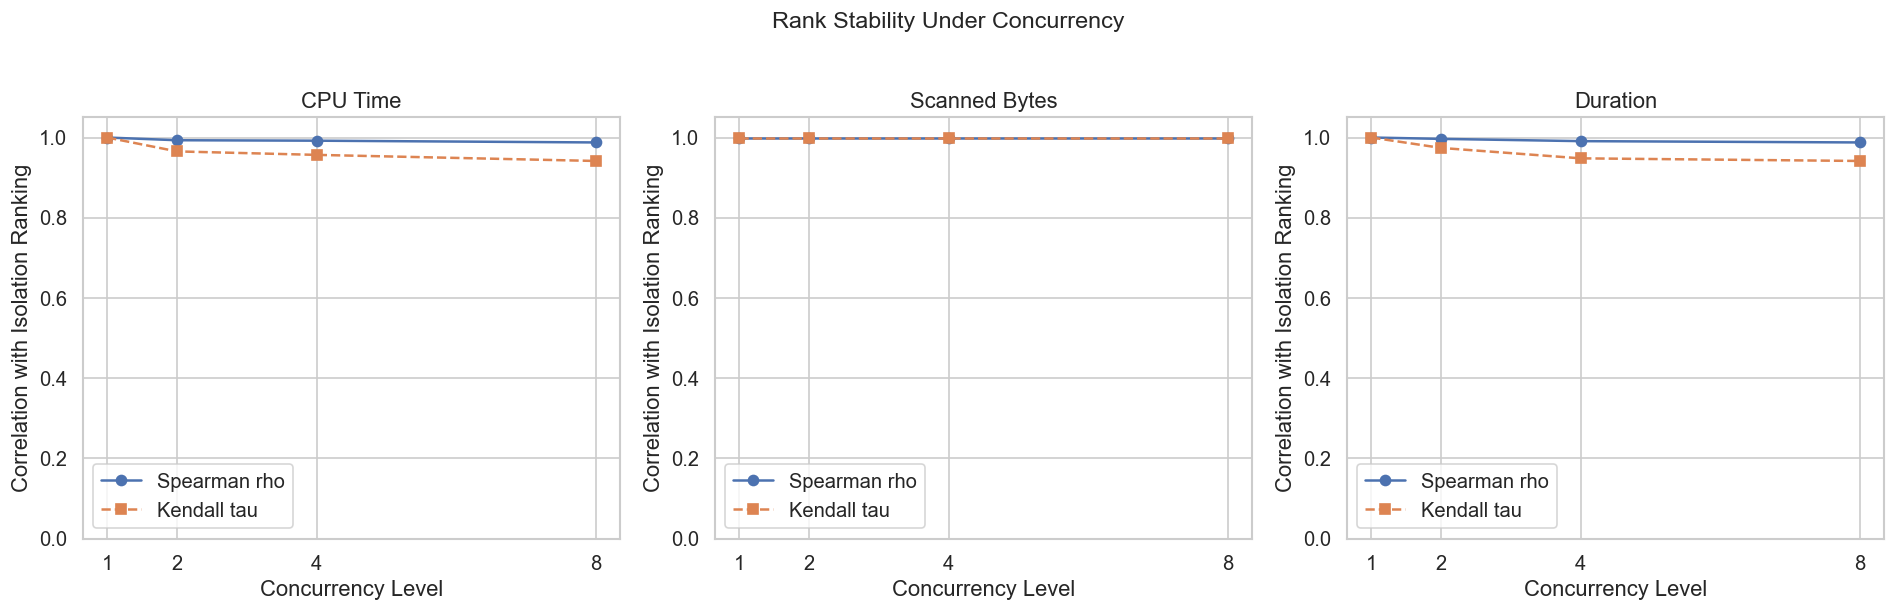

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, m, nice in zip(axes, rank_metrics, nice_names):
    sub = rank_df[rank_df['metric'] == nice]
    ax.plot(sub['concurrency'], sub['spearman_rho'], 'o-', label='Spearman rho')
    ax.plot(sub['concurrency'], sub['kendall_tau'],  's--', label='Kendall tau')
    ax.set_xlabel('Concurrency Level')
    ax.set_ylabel('Correlation with Isolation Ranking')
    ax.set_title(nice)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.set_xticks(CONCURRENCY_LEVELS)

fig.suptitle('Rank Stability Under Concurrency', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## RQ4: Telemetry variance under concurrency

Does concurrency increase the coefficient of variation (CV)?

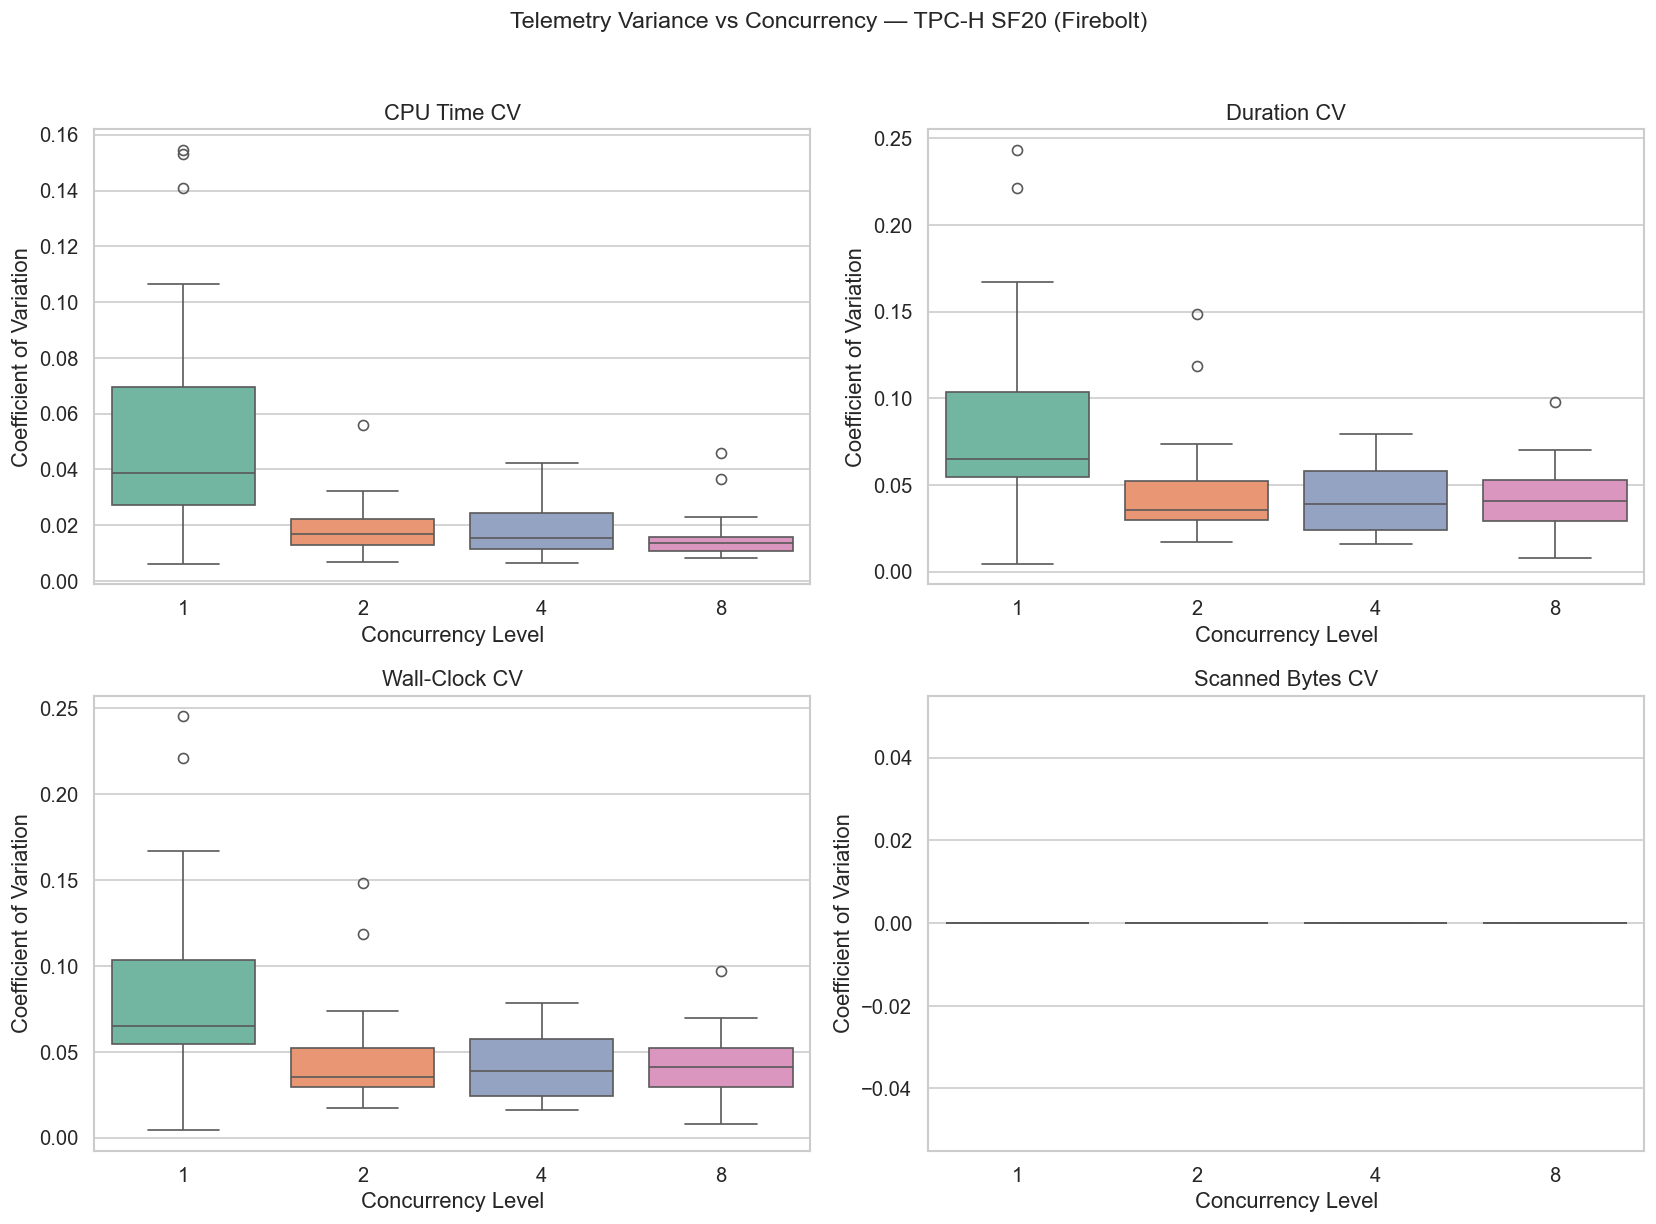

In [9]:
cv_metrics = [
    ('cpu_ms_cv',      'CPU Time CV'),
    ('duration_ms_cv', 'Duration CV'),
    ('wall_ms_cv',     'Wall-Clock CV'),
    ('scan_bytes_cv',  'Scanned Bytes CV'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col, title) in zip(axes.flat, cv_metrics):
    sns.boxplot(data=agg, x='concurrency', y=col, ax=ax, palette='Set2')
    ax.set_title(title)
    ax.set_xlabel('Concurrency Level')
    ax.set_ylabel('Coefficient of Variation')

fig.suptitle('Telemetry Variance vs Concurrency — TPC-H SF20 (Firebolt)',
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## RQ5: Isolation vs Concurrency scatter

Direct scatter: each query's isolation metric value vs its value at each
concurrency level.  Points on the diagonal = no distortion.

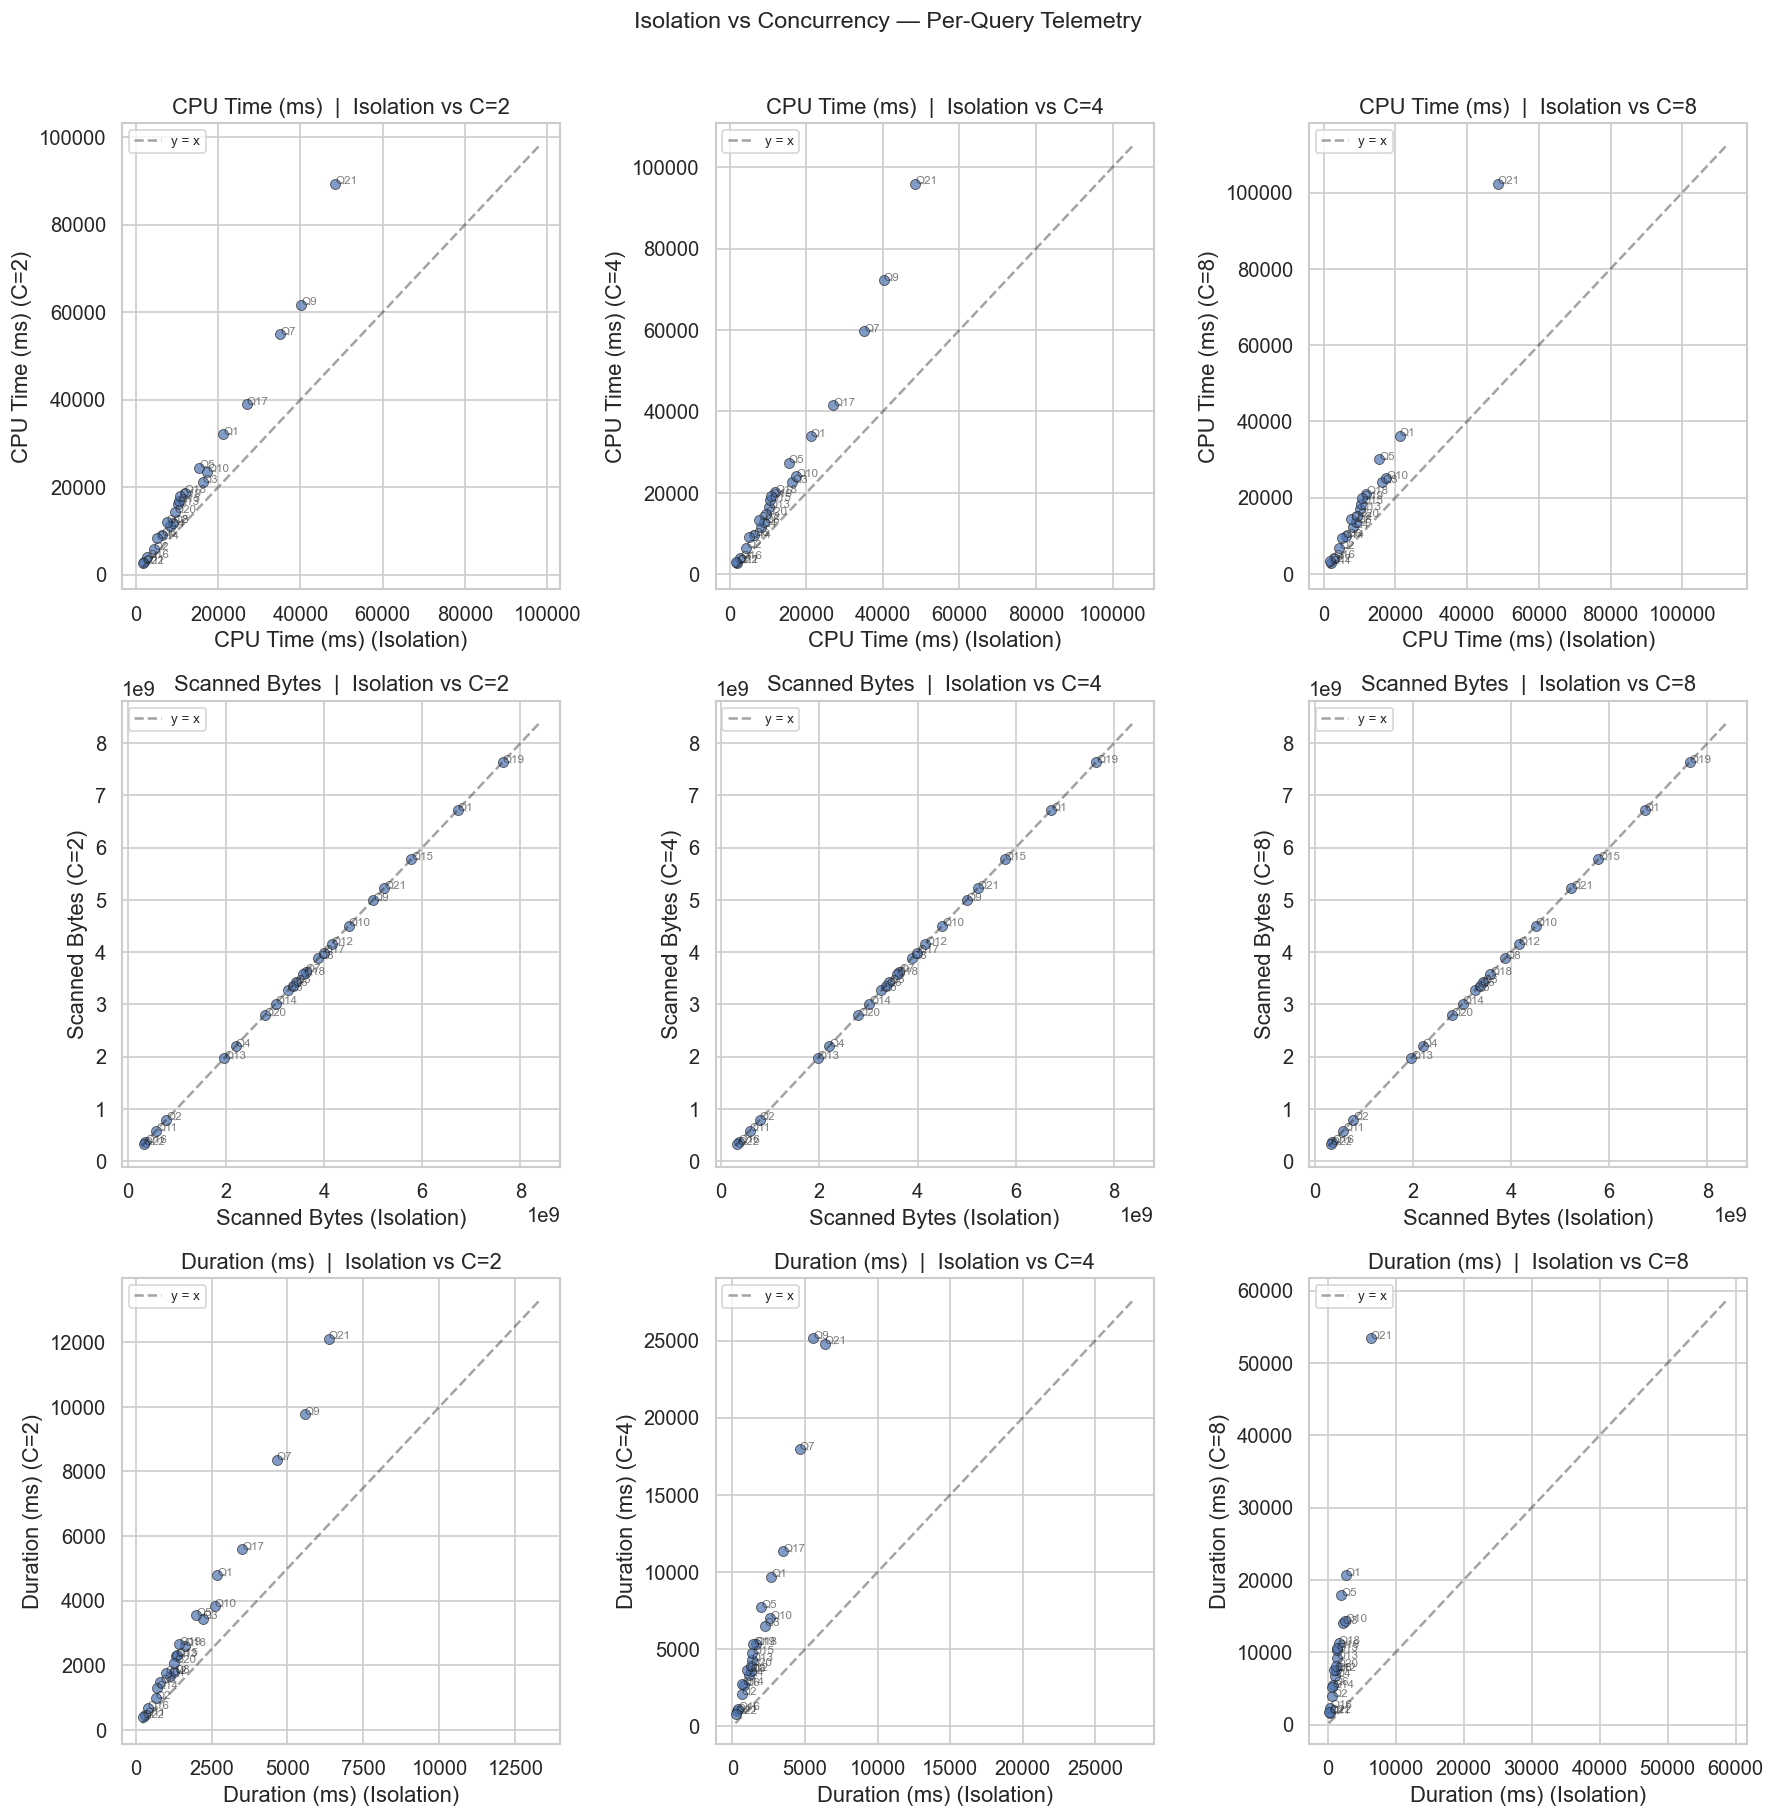

In [10]:
scatter_metrics = [
    ('cpu_ms_mean',      'CPU Time (ms)'),
    ('scan_bytes_mean',  'Scanned Bytes'),
    ('duration_ms_mean', 'Duration (ms)'),
]

conc_no_baseline = [c for c in CONCURRENCY_LEVELS if c > 1]

fig, axes = plt.subplots(len(scatter_metrics), len(conc_no_baseline),
                         figsize=(5 * len(conc_no_baseline),
                                  5 * len(scatter_metrics)))
if len(scatter_metrics) == 1:
    axes = axes[np.newaxis, :]

for row, (m, nice) in enumerate(scatter_metrics):
    iso = agg[agg['concurrency'] == 1].set_index('query_idx')[m]
    for col_i, C in enumerate(conc_no_baseline):
        ax = axes[row, col_i]
        conc_vals = agg[agg['concurrency'] == C].set_index('query_idx')[m]
        common = iso.index.intersection(conc_vals.index)
        x, y = iso.loc[common], conc_vals.loc[common]

        ax.scatter(x, y, alpha=0.7, edgecolors='k', linewidths=0.5)
        lo = min(x.min(), y.min()) * 0.9
        hi = max(x.max(), y.max()) * 1.1
        ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.4, label='y = x')

        for qi in common:
            ax.annotate(f'Q{qi+1}', (x.loc[qi], y.loc[qi]),
                        fontsize=7, alpha=0.6)

        ax.set_xlabel(f'{nice} (Isolation)')
        ax.set_ylabel(f'{nice} (C={C})')
        ax.set_title(f'{nice}  |  Isolation vs C={C}')
        ax.legend(fontsize=8)

fig.suptitle('Isolation vs Concurrency — Per-Query Telemetry',
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

## RQ6: Paired statistical tests — isolation vs each concurrency level

Wilcoxon signed-rank test: is the distribution of metric values
significantly shifted under concurrency?

In [11]:
test_rows = []
for C in conc_no_baseline:
    sub = agg[agg['concurrency'] == C].set_index('query_idx')
    common = baseline.index.intersection(sub.index)
    for m, nice in zip(rank_metrics, nice_names):
        iso_vals  = baseline.loc[common, m].values
        conc_vals = sub.loc[common, m].values
        try:
            stat, p = stats.wilcoxon(iso_vals, conc_vals)
        except ValueError:
            stat, p = np.nan, np.nan
        mean_ratio = np.mean(conc_vals / np.maximum(iso_vals, 1e-9))
        test_rows.append({
            'concurrency': C,
            'metric': nice,
            'n_queries': len(common),
            'mean_ratio': mean_ratio,
            'wilcoxon_stat': stat,
            'wilcoxon_p': p,
            'significant_005': p < 0.05 if not np.isnan(p) else False,
        })

test_df = pd.DataFrame(test_rows)
display(test_df.style.format({
    'mean_ratio': '{:.3f}',
    'wilcoxon_stat': '{:.1f}',
    'wilcoxon_p': '{:.4f}',
}))

,concurrency,metric,n_queries,mean_ratio,wilcoxon_stat,wilcoxon_p,significant_005
0,2,CPU Time,22,1.515,0.0,0.0000,True
1,2,Scanned Bytes,22,1.000,0.0,nan,False
2,2,Duration,22,1.681,0.0,0.0000,True
3,4,CPU Time,22,1.630,0.0,0.0000,True
4,4,Scanned Bytes,22,1.000,0.0,nan,False
5,4,Duration,22,3.414,0.0,0.0000,True
6,8,CPU Time,19,1.705,0.0,0.0000,True
7,8,Scanned Bytes,19,1.000,0.0,nan,False
8,8,Duration,19,6.901,0.0,0.0000,True


## Summary table

In [12]:
summary_rows = []
for C in CONCURRENCY_LEVELS:
    sub = ratios[ratios['concurrency'] == C]
    summary_rows.append({
        'concurrency': C,
        'cpu_ratio_median':      sub['cpu_ratio'].median(),
        'cpu_ratio_max':         sub['cpu_ratio'].max(),
        'scan_ratio_median':     sub['scan_ratio'].median(),
        'scan_ratio_max':        sub['scan_ratio'].max(),
        'duration_ratio_median': sub['duration_ratio'].median(),
        'duration_ratio_max':    sub['duration_ratio'].max(),
    })

summary = pd.DataFrame(summary_rows).set_index('concurrency')
display(summary.style.format('{:.3f}').background_gradient(
    cmap='Reds', axis=None, vmin=1.0))

print('\nValues > 1.0 indicate telemetry inflation under concurrency.')
print('Values ~= 1.0 indicate the metric is stable across concurrency levels.')

,cpu_ratio_median,cpu_ratio_max,scan_ratio_median,scan_ratio_max,duration_ratio_median,duration_ratio_max
concurrency,,,,,,
1,1.000,1.000,1.000,1.000,1.000,1.000
2,1.527,1.843,1.000,1.000,1.705,1.902
4,1.613,1.979,1.000,1.000,3.304,4.515
8,1.681,2.111,1.000,1.000,6.952,8.973



Values > 1.0 indicate telemetry inflation under concurrency.
Values ~= 1.0 indicate the metric is stable across concurrency levels.
